Power analysis for the effect size of the birth year coefficient

In [1]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np
from tqdm import tqdm

In [2]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')
# # keep only classification_label=1 and snbb
# combined_df = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

In [3]:
min_age = 25
max_age = 30

# volumes df
volumes = combined_df[(combined_df['age_in_years'] >= min_age) & (combined_df['age_in_years'] < max_age)]

# metadata df
# remove duplicates based on subject_id
metadata = volumes.drop_duplicates(subset=['subject_id'])
print(f"shape of {min_age} - {max_age} years old metadata after removing duplicates: {metadata.shape}")

# type of values in the "age_at_scan" column
print(volumes['age_in_years'].dtype)

# 1. Convert the column to numeric (floats)
volumes['age_in_years'] = pd.to_numeric(volumes['age_in_years'], errors='coerce')

shape of 25 - 30 years old metadata after removing duplicates: (1082, 26)
object


In [4]:
# significant_rois = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/significant_rois_late_twenties.csv")

# # take the  first columns and make is a list
# list_of_significant_rois = significant_rois['region_label']

# # make it a list
# list_of_significant_rois = list(list_of_significant_rois)

list_of_significant_rois = list([421, 422, 448, 449])

In [5]:
n_list = [25, 33, 50, 70, 100, 135, 175, 225]
reps = 100  # Number of random samplings per N
simulation_results = []

In [6]:
# TODO - add weighting to the 

  0%|          | 0/4 [00:00<?, ?it/s]

Starting simulation for ROI 421...


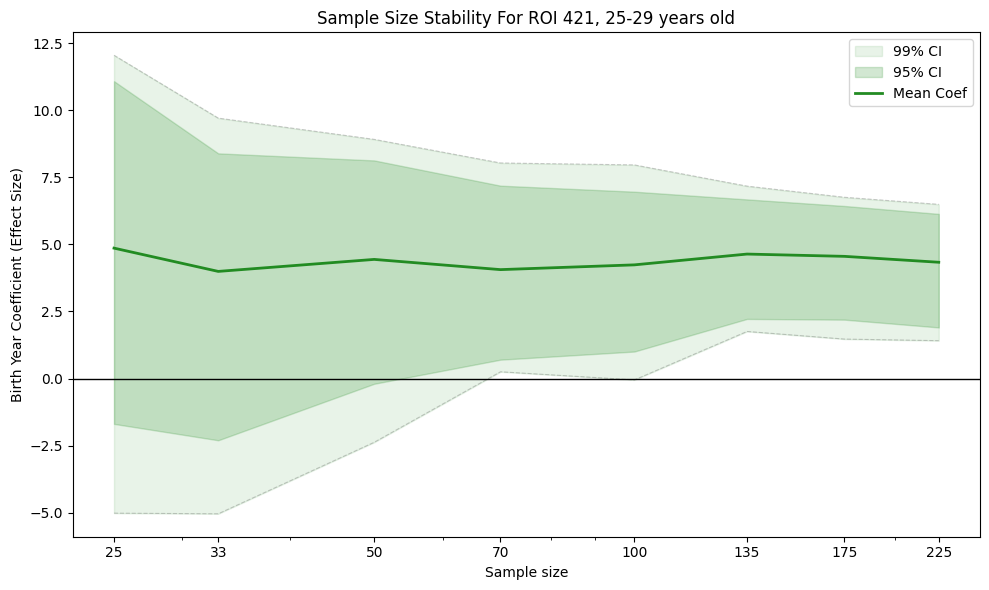

 25%|██▌       | 1/4 [00:04<00:12,  4.06s/it]

Starting simulation for ROI 422...


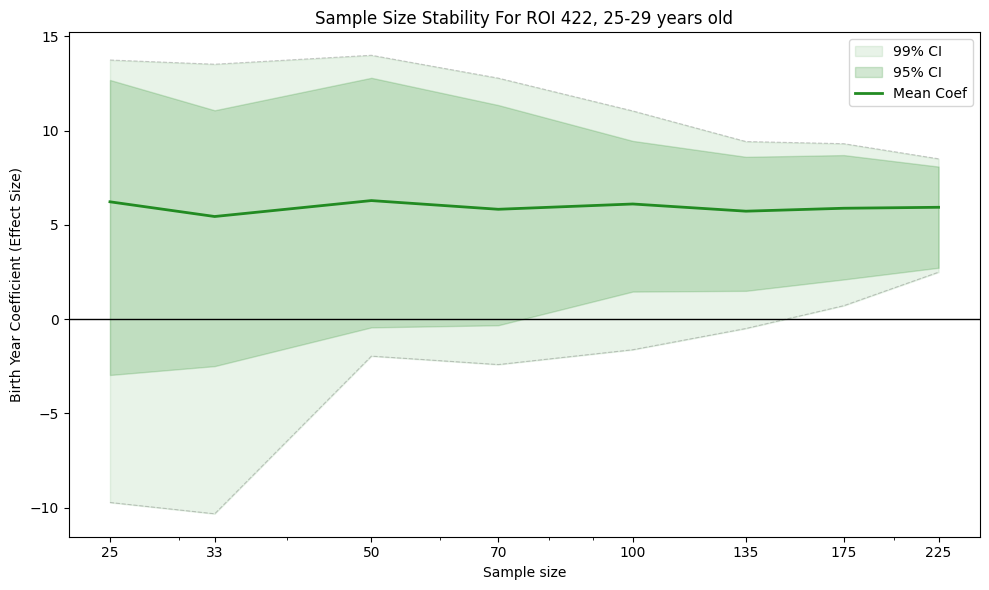

 50%|█████     | 2/4 [00:08<00:08,  4.07s/it]

Starting simulation for ROI 448...


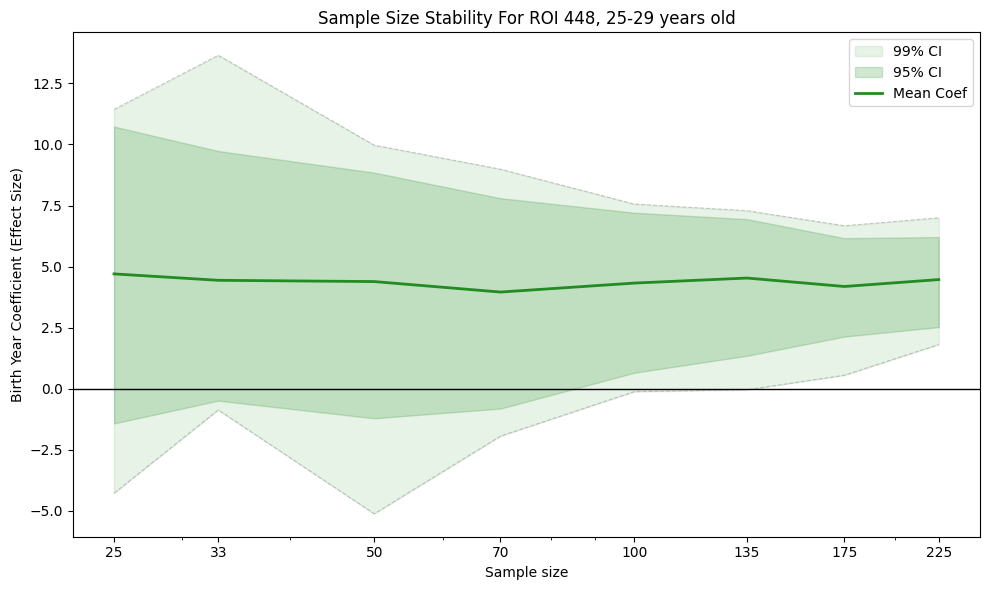

 75%|███████▌  | 3/4 [00:12<00:04,  4.07s/it]

Starting simulation for ROI 449...


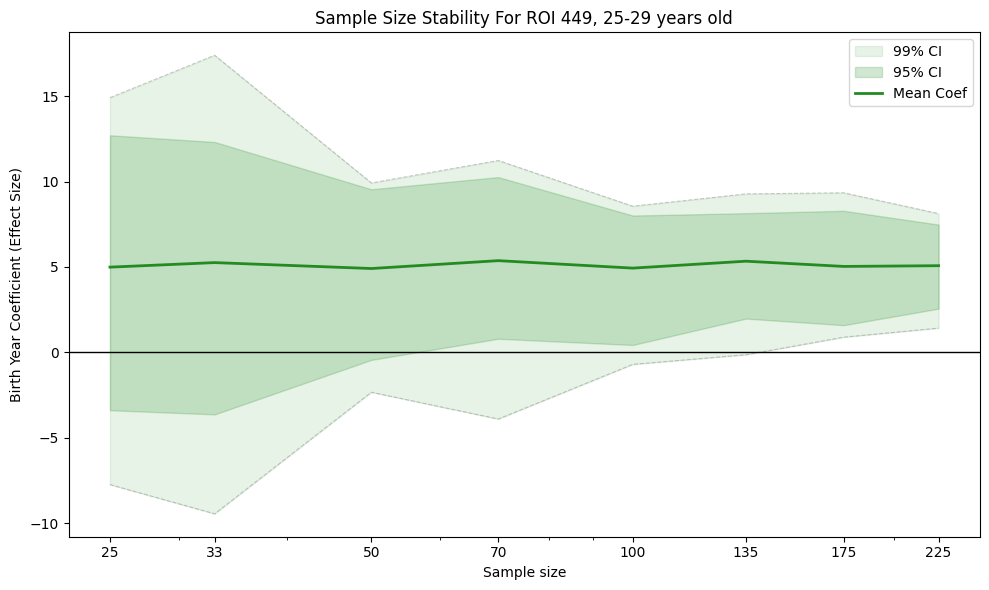

100%|██████████| 4/4 [00:16<00:00,  4.07s/it]


In [10]:
# 2. Run Simulation
for roi in tqdm(list_of_significant_rois):
    print(f"Starting simulation for ROI {roi}...")
    
    # Storage for THIS specific ROI's iterations
    roi_simulation_results = []
    
    # Filter for the specific ROI first to speed up sampling
    df_sim = volumes[volumes['region_label'] == roi].copy()
    
    # Define age range for the title
    min_age = int(df_sim['age_in_years'].min())
    max_age = int(df_sim['age_in_years'].max())

    for n in n_list:
        for r in range(reps):
            try:
                # Sample n scans randomly
                sample_df = df_sim.sample(n=n, replace=False)
            
                # Fit the OLS model
                model = smf.ols(
                    'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years',
                    data=sample_df
                ).fit()
                
                roi_simulation_results.append({
                    'sample_size': n,
                    'iteration': r,
                    'coef': model.params['birth_year'],
                    'p_val': model.pvalues['birth_year']
                })
            except Exception as e:
                continue

    # Create DataFrame for current ROI
    sim_df = pd.DataFrame(roi_simulation_results)
    
    if sim_df.empty:
        print(f"No results for ROI {roi}, skipping plot.")
        continue

    # 3. Calculate Percentiles for THIS ROI
    stats = sim_df.groupby('sample_size')['coef'].agg([
        'mean',
        lambda x: np.percentile(x, 0.5),   # 99% Lower
        lambda x: np.percentile(x, 99.5),  # 99% Upper
        lambda x: np.percentile(x, 2.5),   # 95% Lower
        lambda x: np.percentile(x, 97.5)   # 95% Upper
    ]).reset_index()

    stats.columns = ['sample_size', 'mean', 'low_99', 'high_99', 'low_95', 'high_95']

    # 1. Create masks for when the CIs are "significant" (don't include 0)
    mask_95 = (stats['low_95'] * stats['high_95'] > 0)
    mask_99 = (stats['low_99'] * stats['high_99'] > 0)

    # 2. Find the last sample size that was NOT significant (included 0)
    # If the mask is all True, max_fail will be None or empty
    failed_indices_95 = stats[~mask_95]['sample_size']
    failed_indices_99 = stats[~mask_99]['sample_size']

    last_fail_95 = failed_indices_95.max() if not failed_indices_95.empty else -1
    last_fail_99 = failed_indices_99.max() if not failed_indices_99.empty else -1

    # 3. The "Stable" sample size is the first one larger than the last failure
    stable_95 = stats[stats['sample_size'] > last_fail_95]['sample_size'].min()
    stable_99 = stats[stats['sample_size'] > last_fail_99]['sample_size'].min()

    simulation_results.append({
        'roi': roi,
        'mean_coef': stats['mean'].mean(),
        'first_sample_size_95': stable_95,
        'first_sample_size_99': stable_99
    })
    # 4. Create the Funnel Plot for THIS ROI
    plt.figure(figsize=(10, 6))

    # --- Shading Layers ---
    plt.fill_between(stats['sample_size'], stats['low_99'], stats['high_99'], 
                     color='forestgreen', alpha=0.1, label='99% CI')
    plt.fill_between(stats['sample_size'], stats['low_95'], stats['high_95'], 
                     color='forestgreen', alpha=0.2, label='95% CI')

    # --- Border Lines ---
    plt.plot(stats['sample_size'], stats['low_99'], color='gray', linestyle='--', lw=0.8, alpha=0.4)
    plt.plot(stats['sample_size'], stats['high_99'], color='gray', linestyle='--', lw=0.8, alpha=0.4)

    # --- Central Trend ---
    plt.plot(stats['sample_size'], stats['mean'], color='forestgreen', lw=2, label='Mean Coef')

    # Formatting
    plt.xscale('log')
    plt.xticks(n_list, labels=[str(x) for x in n_list])
    plt.axhline(0, color='black', lw=1)
    plt.xlabel('Sample size')
    plt.ylabel('Birth Year Coefficient (Effect Size)')
    plt.legend()
    plt.title(f'Sample Size Stability For ROI {roi}, {min_age}-{max_age} years old')

    # Show plot for this ROI
    plt.tight_layout()
    plt.show()